<a href="https://colab.research.google.com/github/Armina101/Postpartum-depression-prediction-model/blob/main/postpartum_depression_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Pre-processing**

## **Importing all needed libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## **Read Dataset**

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/Armina101/Postpartum-depression-prediction-model/refs/heads/main/THP_clean.csv')

In [3]:
df.head()

,newid,interviewer,uc,grandmother,employed_mo,income_mo,income_hh,genhealth,edu_mo,edu_fa,...,infantdev_1y,infantdev_1y_f,parentinputs_infancy,parentinputs_infancy_f,infantdev,infantdev_f,motherfinancial_7y,motherfinancial_7y_f,socialsupport,socialsupport_f
0,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,7.319728,...,-1.550027,-0.914190,0.845854,0.341055,-1.155602,-0.975243,NaN,NaN,1.496326,NaN
1,226.0,1.0,1,No,No,0.0,60.0,Very good,0.0,8.000000,...,0.919651,0.044339,2.737210,0.550107,0.587643,0.244921,-0.064279,-0.346433,2.569177,1.731267
2,222.0,6.0,1,Yes,No,0.0,200.0,Moderate,7.0,9.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.521870,-0.295887,1.275779,NaN
3,3.0,1.0,1,No,No,0.0,150.0,Good,0.0,5.000000,...,1.589225,0.971888,0.634669,0.429139,0.326545,0.626777,0.521984,-0.163072,-0.521288,-0.880748
4,217.0,3.0,1,No,No,0.0,250.0,0,5.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.521984,-0.163072,1.275779,NaN


In [4]:
df.tail()

,newid,interviewer,uc,grandmother,employed_mo,income_mo,income_hh,genhealth,edu_mo,edu_fa,...,infantdev_1y,infantdev_1y_f,parentinputs_infancy,parentinputs_infancy_f,infantdev,infantdev_f,motherfinancial_7y,motherfinancial_7y_f,socialsupport,socialsupport_f
1198,546.0,5.0,40,Yes,No,0.0,150.0,Very good,0.0,10.000000,...,-0.213161,-0.325892,0.746556,0.541312,0.176705,-0.694231,-0.064279,-0.346433,0.204220,-0.035893
1199,NaN,NaN,40,NaN,NaN,NaN,NaN,NaN,NaN,7.319728,...,-0.315063,-0.402695,0.425044,NaN,0.903029,0.132893,NaN,NaN,-0.025040,NaN
1200,594.0,5.0,40,Yes,No,0.0,80.0,Moderate,4.0,7.000000,...,1.145054,0.341715,0.746556,0.541312,1.455266,0.502727,0.521984,-0.163072,0.747689,0.313829
1201,568.0,5.0,40,No,Yes,NaN,NaN,Good,5.0,8.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.449251,NaN,-0.380235,NaN
1202,NaN,NaN,40,NaN,NaN,NaN,NaN,NaN,NaN,7.319728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Sanity check of data**

In [5]:
df.shape

(1203, 394)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1203 entries, 0 to 1202
Columns: 394 entries, newid to socialsupport_f
dtypes: float64(366), int64(11), object(17)
memory usage: 3.6+ MB


In [7]:
#checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [8]:
#checking for garbage values
for i in df.select_dtypes(include='object').columns:
  print(df[i].value_counts())
  print("***"*10)

grandmother
No     538
Yes    347
Name: count, dtype: int64
******************************
employed_mo
No     781
Yes    104
Name: count, dtype: int64
******************************
genhealth
Good         364
Moderate     251
Very good    184
0             70
Bad           16
Name: count, dtype: int64
******************************
ideal_no_kids
4     267
3     262
2     237
5      58
6      18
.d     11
7      10
1       9
8       8
0       4
Name: count, dtype: int64
******************************
mo_185
Yes    558
No     301
Name: count, dtype: int64
******************************
mo_358
not played at all    602
.25                  105
once or twice        102
.5                    56
.75                   20
Name: count, dtype: int64
******************************
mo_360
Yes    517
No     368
Name: count, dtype: int64
******************************
ch_27
Yes    704
No     170
Name: count, dtype: int64
******************************
ch_28
Yes    744
No     130
Name: count, dtype: i

## **Exploratory Data Analysis**

In [9]:
#descriptive statistics
df.describe()

,newid,interviewer,uc,income_mo,income_hh,edu_mo,edu_fa,no_kids_over5_dead,no_kids_1_5_dead,no_kids_less1_dead,...,infantdev_1y,infantdev_1y_f,parentinputs_infancy,parentinputs_infancy_f,infantdev,infantdev_f,motherfinancial_7y,motherfinancial_7y_f,socialsupport,socialsupport_f
count,885.000000,885.000000,1203.000000,876.000000,756.000000,885.000000,1203.000000,882.000000,881.000000,881.000000,...,712.000000,7.080000e+02,816.000000,5.860000e+02,740.000000,7.030000e+02,885.000000,8.500000e+02,1120.000000,5.840000e+02
mean,446.225989,4.672316,20.358271,4.332192,141.707143,4.532203,7.319728,0.020408,0.037457,0.254257,...,0.202339,7.455650e-10,0.185357,-3.583618e-09,0.133936,1.593172e-10,0.177863,4.270588e-09,0.346108,1.469041e-09
std,256.597500,2.254451,11.440891,15.539970,116.350589,4.182804,3.226069,0.141472,0.217851,0.622537,...,0.986870,8.181502e-01,1.191635,9.470208e-01,1.007829,9.371984e-01,1.047386,8.890144e-01,1.083957,7.565686e-01
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-4.269506,-4.648146e+00,-4.007296,-2.417459e+00,-3.322134,-4.993645e+00,-1.108133,-4.792471e-01,-2.809055,-2.106218e+00
25%,225.000000,3.000000,10.000000,0.000000,70.000000,0.000000,7.000000,0.000000,0.000000,0.000000,...,-0.481443,-4.741491e-01,-0.516389,2.669969e-01,-0.541004,-5.238761e-01,-1.108133,-4.792471e-01,-0.380235,-5.160580e-01
50%,447.000000,5.000000,20.000000,0.000000,100.000000,5.000000,7.319728,0.000000,0.000000,0.000000,...,0.281445,2.411396e-02,0.260971,4.462136e-01,0.206483,2.035729e-02,0.521984,-1.630720e-01,0.385548,1.932745e-02
75%,668.000000,6.000000,30.000000,0.000000,180.000000,8.000000,10.000000,0.000000,0.000000,0.000000,...,0.969147,5.129925e-01,0.746556,5.413125e-01,0.876496,6.015202e-01,0.521984,-1.630720e-01,1.095594,5.129678e-01
max,889.000000,9.000000,40.000000,100.000000,800.000000,18.000000,16.000000,1.000000,3.000000,6.000000,...,2.511270,2.217049e+00,3.995981,7.250453e-01,2.439257,2.655170e+00,4.615942,4.415358e+00,2.739945,1.797304e+00


In [10]:
df.describe(include='object')

,grandmother,employed_mo,genhealth,ideal_no_kids,mo_185,mo_358,mo_360,ch_27,ch_28,ch_29,ch_30,ch_31,ch_32,ch_33,ch_34,ch_35,ch_36
count,885,885,885,884,859,885,885,874,874,874,874,874,874,874,874,874,850
unique,2,2,5,10,2,5,2,2,2,2,2,2,2,2,2,2,2
top,No,No,Good,4,Yes,not played at all,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,No,Yes
freq,538,781,364,267,558,602,517,704,744,476,507,793,814,857,581,598,431


In [11]:
#target class name
input_target_class = "hamd_6m"

#columns to be removed
input_columns_to_remove = []

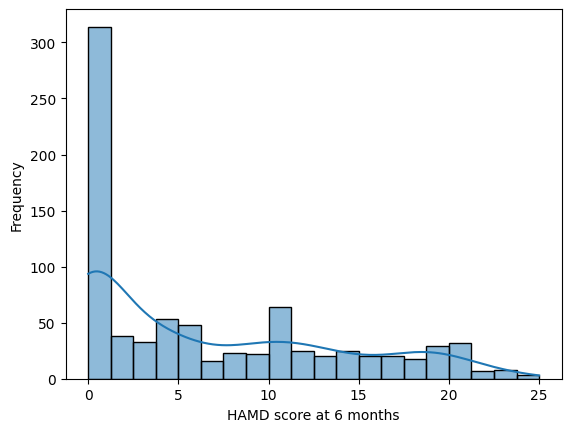

In [15]:
#checking distribution of target class
sns.histplot(df[input_target_class], bins=20, kde=True)
plt.xlabel("HAMD score at 6 months")
plt.ylabel("Frequency")
plt.show()

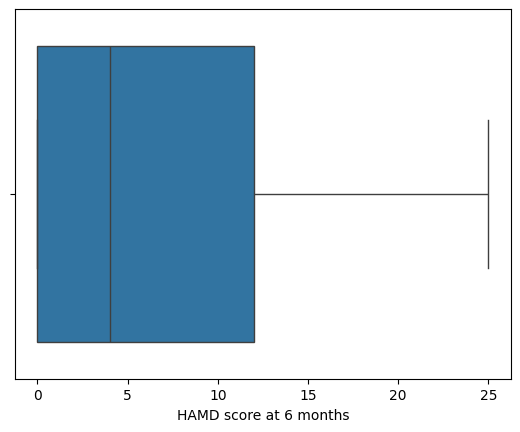

In [14]:
sns.boxplot(x=df[input_target_class])
plt.xlabel("HAMD score at 6 months")
plt.show()

In [19]:
#checking value counts
print(df[input_target_class].value_counts().sort_index())

hamd_6m
0.0     282
1.0      32
2.0      38
3.0      33
4.0      53
5.0      26
6.0      22
7.0      16
8.0      23
9.0      22
10.0     34
11.0     30
12.0     25
13.0     20
14.0     25
15.0      8
16.0     12
17.0     20
18.0     18
19.0     29
20.0     20
21.0     12
22.0      7
23.0      8
24.0      2
25.0      1
Name: count, dtype: int64


In [ ]:
#histogram to understand the distribution
import warnings
warnings.filterwarnings('ignore')
for i in df.select_dtypes(include='number').columns:
  sns.histplot(data=df, x=i)
  plt.show()

In [ ]:
#boxplot to identify outliers

## **Missing Values Treatment**

In [ ]:
#method of imputing missing value


In [ ]:
pd.set_option('display.max_rows', None)
missing_percent = df.isnull().sum() / df.shape[0] * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

### **Fixing Garbage Values**

In [ ]:
# df['genhealth'] = df['genhealth'].replace("0", np.nan)
# df['ideal_no_kids'] = df['ideal_no_kids'].replace("0", np.nan)
# df['ideal_no_kids'] = pd.to_numeric(df['ideal_no_kids'], errors='coerce')

In [ ]:
# mapping = {
   # "not played at all": 0.0,
  #  "once or twice": 0.25
# }
# df["mo_358"] = df["mo_358"].replace(mapping)
# df["mo_358"] = pd.to_numeric(df["mo_358"], errors="coerce")

### **Fixing Missing Values**

In [ ]:
# df.isnull().sum()

In [ ]:
# df.isnull().sum()/df.shape[0]*100

In [ ]:
# new plan
# drop all columns with more than 30% NaN values
# before establishing relationships with histogram